# Predicción de Precios con Redes Neuronales Recurrentes (LSTM)
## Primavera 2025
## Alumno : **Leonardo Daniel Rosas Rios**

<img src="Logo_de_la_BUAP.svg.png" alt="Logo BUAP" width="400px" height="300px">


## Empresa: NVIDIA Corporation

NVIDIA es una de las compañías tecnológicas más influyentes en el ámbito de la inteligencia artificial, gráficos por computadora y procesamiento de datos. Por su alta volatilidad y crecimiento en los mercados, sus acciones representan un caso interesante para aplicar modelos de series temporales como redes

In [18]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from alpha_vantage.timeseries import TimeSeries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score


## Obtencion de datos

Los datos históricos de precios de la acción de NVIDIA (ticker: `NVDA`) fueron obtenidos desde la API gratuita de **Alpha Vantage**, parahacer esto, hayq ue entrar y registrar un correo electronico en su pagina para poder obtener la key de acceso. Estos datos cubren precios de apertura, máximo, mínimo, cierre y volumen diario.

Las columnas renombradas utilizadas fueron:

- `Open`: precio de apertura
- `High`: precio máximo del día
- `Low`: precio mínimo del día
- `Close`: precio de cierre
- `Volume`: volumen de transacciones

In [20]:

api_key = 'J9G8PRXXSGDLDFK8'

# Crear una instancia de TimeSeries
ts = TimeSeries(key=api_key, output_format='pandas')

# Descargar datos históricos diarios de Nvidia
nvidia, meta_data = ts.get_daily(symbol='NVDA', outputsize='full')

# Guardamos el archivo en un csv
nvidia.to_csv('nvidia_historical_data.csv')

nvidia.head()


,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2025-05-01,113.08,114.9400,111.30,111.61,236121507.0
2025-04-30,104.47,108.9200,104.08,108.92,235044611.0
2025-04-29,107.67,110.1999,107.44,109.02,170444263.0
2025-04-28,109.69,110.3699,106.02,108.73,207708479.0
2025-04-25,106.85,111.9200,105.73,111.01,251064672.0


In [21]:
nvidia.columns

Index(['1. open', '2. high', '3. low', '4. close', '5. volume'], dtype='object')

In [22]:
# Renombramos las columnas de Alpha Vantage a nombres más limpios
nvidia = nvidia.rename(columns={
    '1. open': 'Open',
    '2. high': 'High',
    '3. low': 'Low',
    '4. close': 'Close',
    '5. volume': 'Volume'
})

# Asegurarse de que las fechas estén en orden ascendente
nvidia


,Open,High,Low,Close,Volume
date,,,,,
2025-05-01,113.08,114.9400,111.30,111.61,236121507.0
2025-04-30,104.47,108.9200,104.08,108.92,235044611.0
2025-04-29,107.67,110.1999,107.44,109.02,170444263.0
2025-04-28,109.69,110.3699,106.02,108.73,207708479.0
2025-04-25,106.85,111.9200,105.73,111.01,251064672.0
...,...,...,...,...,...
1999-11-05,30.00,30.2500,26.88,28.25,1284100.0
1999-11-04,27.75,29.9400,27.75,29.19,2625700.0
1999-11-03,26.00,28.1300,25.81,27.44,4191000.0


### Rendimientos logarítmicos

Se calculó el **rendimiento logarítmico diario** como:

$$
\log\left(\frac{P_t}{P_{t-1}}\right)
$$

Esto permite estabilizar la varianza de la serie y trabajar con diferencias relativas en lugar de valores absolutos, lo que mejora la eficiencia del modelo y reduce sesgos por escala.

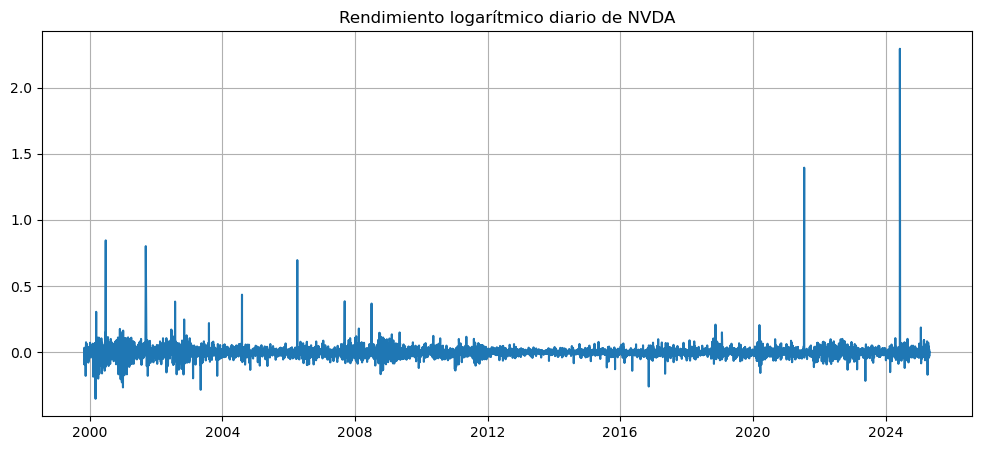

In [23]:
nvidia['log_return'] = np.log(nvidia['Close'] / nvidia['Close'].shift(1))
nvidia.dropna(inplace=True)

plt.figure(figsize=(12, 5))
plt.plot(nvidia['log_return'])
plt.title('Rendimiento logarítmico diario de NVDA')
plt.grid(True)
plt.show()



### Normalización

Los precios de cierre se escalaron usando `MinMaxScaler` para garantizar que todos los valores estén entre 0 y 1, lo que es fundamental para modelos LSTM que son sensibles a la escala de entrada.

In [24]:


# Escalamos el precio de cierre
scaler = MinMaxScaler()
nvidia['scaled_close'] = scaler.fit_transform(nvidia[['Close']])

# Función para crear las secuencias de entrenamiento
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(nvidia['scaled_close'].values, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# División entre entrenamiento y prueba
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


## Modelo LSTM

El modelo se compone de:

- 2 capas LSTM con 50 unidades cada una
- 1 capa densa de salida
- Función de pérdida: mean_squared_error
- Optimizador: Adam (por su adaptabilidad y velocidad de convergencia)

El tamaño de ventana seq_length fue de 60 días, lo que significa que el modelo aprende a predecir el siguiente precio basándose en los 60 días anteriores.

In [26]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

El modelo es entrenado con:

- 20 épocas
- Lote de 32 muestras
- Validación con el 20% de los datos
- Pérdida (loss) y pérdida de validación (val_loss) decreciente, lo que indica buen aprendizaje

In [27]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0063 - val_loss: 5.5136e-05
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 9.8537e-04 - val_loss: 4.8087e-05
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 9.5353e-04 - val_loss: 4.4740e-05
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 4.3457e-04 - val_loss: 3.6520e-05
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3.1083e-04 - val_loss: 5.1024e-05
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 6.3831e-04 - val_loss: 5.0150e-05
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.3114e-04 - val_loss: 2.9153e-05
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.3013e-04 - val_loss: 3.7393e-05
Epoch 9/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.4490e-04 - val_loss: 3.0248e-05
Epoch 10/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.1503e-04 - val_loss: 4.3279e-05
Epoch 11/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


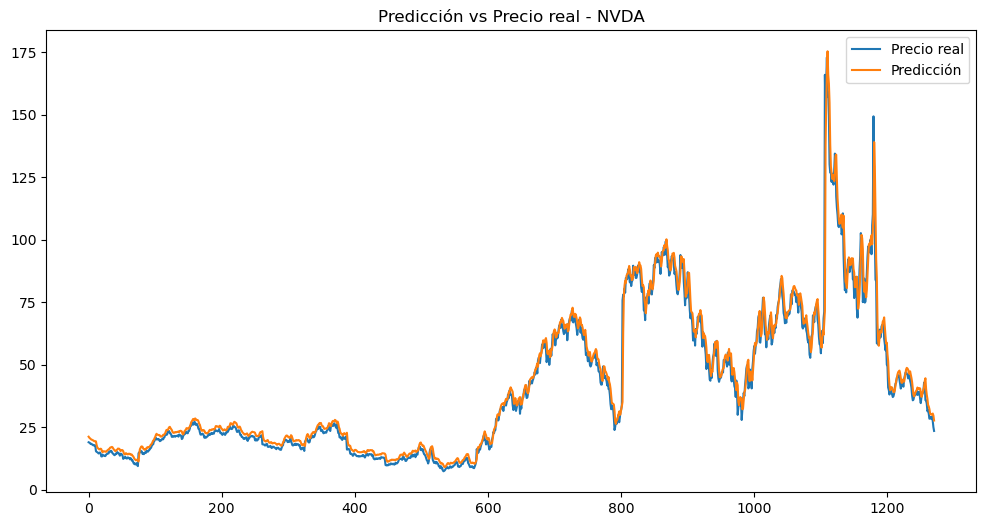

In [10]:
predictions = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predictions.reshape(-1, 1))
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12,6))
plt.plot(real_prices, label='Precio real')
plt.plot(predicted_prices, label='Predicción')
plt.legend()
plt.title('Predicción vs Precio real - NVDA')
plt.show()

## Resultados

El modelo fue capaz de predecir los precios con buena aproximación. En la visualización final se muestra la comparación entre:

- Precio real (línea azul)
- Precio predicho por el modelo (línea naranja)

La curva predicha sigue de forma aceptable la tendencia del precio real, lo que valida el uso de LSTM en problemas de series temporales como este.

In [12]:

rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))
print("RMSE:", rmse)

RMSE: 4.839358784251863


In [13]:
mae = mean_absolute_error(real_prices, predicted_prices)
print("MAE:", mae)

MAE: 2.720161432357776


In [14]:
r2 = r2_score(real_prices, predicted_prices)
print("R² Score:", r2)

R² Score: 0.9719722237193261


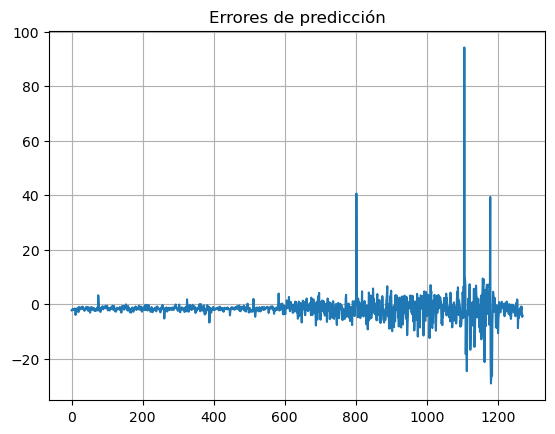

In [15]:
errores = real_prices - predicted_prices
plt.plot(errores)
plt.title("Errores de predicción")
plt.grid(True)
plt.show()


## Evaluación del modelo

El modelo fue entrenado durante 20 épocas con un tamaño de lote de 32. El descenso progresivo en la función de pérdida (loss y val_loss) indica una buena capacidad de generalización.

Para validar el desempeño del modelo, se calcularon las siguientes métricas sobre el conjunto de prueba:

- **Error cuadrático medio (RMSE):** 4.84
- **Coeficiente de determinación (R²):** 0.972

Esto significa que el modelo comete un error promedio de aproximadamente $4.84 por predicción, y es capaz de explicar el 97.2% de la variación observada en los precios reales de NVIDIA.

Ambos datps  nos dicen que el modelo LSTM está bien ajustado y generaliza adecuadamente sobre datos no vistos. La precisión obtenida es especialmente destacable considerando la naturaleza volátil del mercado accionario.

La comparación entre los precios reales y los precios predichos muestra que el modelo logra seguir de forma consistente la tendencia general del mercado, aunque puede suavizar los picos o valles extremos, lo cual es una característica habitual en modelos LSTM.


## Conclusiones

- Las LSTM se adaptan de forma eficiente a la predicción de precios financieros debido a su capacidad de capturar patrones secuenciales.
- El modelo alcanzó una precisión razonable utilizando solamente el precio de cierre como entrada.
- Para mejorar el modelo, se podrían incluir variables adicionales como volumen, indicadores técnicos (RSI, MACD), o datos de sentimiento del mercado.
- Esta metodología puede aplicarse a cualquier activo financiero con historial de precios para propósitos de trading algorítmico o análisis cuantitativo.

Este trabajo evidencia cómo las técnicas de deep learning pueden integrarse al análisis financiero de manera efectiva.
